## MultiAgent Colab
Multi Agent are independent actors powered by LLM, connected in a specific way.

Each Agent have its won prompt, LLM, tools, and other custom code to best collborate with other agents. 

2 condieerations about multi-agent workflows: - What are multiple independent agents, how are those connected.

Each agent is a node, and their conn are represented as an edge. The control flow is managed by edges. They comm by adding graph state. 

### Multi Ag4ent collab:
- In this exaple the diff agents collanb on a shared scratchpad of messages this means that all the work either of them do is visible to other.
- This has the benefits taht other agents can see all indi steps done. 
- This has downside, it overly berbose and unncessary to pass ALL this information along. And sometimes the final answer from an agent is needed. 
- We call this caollab because of the shred nature of scratchpad



In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

import os
from dotenv import load_dotenv
from langchain_aws import ChatBedrockConverse
load_dotenv()

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' 

model = ChatBedrockConverse(model= "us.anthropic.claude-sonnet-4-6")

In [2]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition, ToolNode
from langgraph.types import Command

from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langchain.agents import create_agent

from operator import add
from typing import TypedDict, Annotated, Literal

from langchain_tavily import TavilySearch
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

c:\Data\Codes\AgenticAITraining\Lanchain_LangGraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


#### Defining the tools

In [3]:
# DuckDuckGo Search
duckduckgo_tool = DuckDuckGoSearchRun()

repl = PythonREPL()

In [4]:
@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate your chart."],):
    '''Use this to execute python code If you wnat to see the output of a value you should print it out with `print(...)`. This is visible to the user.'''
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [5]:
print("Testing python_repl_tool:")
print(python_repl_tool.name)
print(python_repl_tool.description)

Testing python_repl_tool:
python_repl_tool
Use this to execute python code If you wnat to see the output of a value you should print it out with `print(...)`. This is visible to the user.


### Create Graph

Now we have deffiend our tools, and made some helper fucntions, we will create the individual agents below and tell them how to talk to each other usign LG.

In [12]:
def make_system_prompt(suffix: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

In [13]:
def get_next_node(last_message: BaseMessage, goto: str):
    '''Decide whether to end the collaboration or continue to the next agent.'''
    if 'FINAL ANSWER' in last_message.content:
        return END
    else:
        return goto

#### Researcher Agent and Node

In [14]:
researcher_agent = create_agent(
    model, 
    tools = [duckduckgo_tool], 
    system_prompt = make_system_prompt(
        "You can only do research. You are working with a chart_generator colleague."
    )
)

In [15]:
def researcher_node(state: MessagesState) -> Command[Literal['chart_generator', '__end__']]:
    result = researcher_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "chart_generator")

    # wrap in a human message, AI message at the last position of the input messages
    result["messages"][-1] = HumanMessage(
        content = result['messages'][-1].content, name = 'researcher'
    )

    return Command(
        update = {'messages': result['messages']}, 
        goto = goto
    )

#### Chart Generator and Node

In [16]:
chart_agent = create_agent(
    model, 
    [python_repl_tool],
    system_prompt = make_system_prompt(
        'You can only generate chart You are working with a researcher colleague.'
    )
)

def chart_node(state: MessagesState) -> Command[Literal['researcher', '__end__']]:
    result = chart_agent.invoke(state)
    goto = get_next_node(result['messages'][-1], 'researcher'),

    # Wrapping it as Human Message
    result['messages'][-1] = HumanMessage(
        content = result['messages'][-1].content, name = 'chart_generator'
    )

    return Command(
        update = {'messages': result['messages']},
        goto = goto
    )

#### Defining the Grapah

We can now put it all together and define the graph!

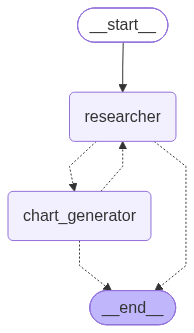

In [17]:
workflow = StateGraph(MessagesState)
workflow.add_node('researcher', researcher_node)
workflow.add_node('chart_generator', chart_node)

workflow.add_edge(START, 'researcher')

graph = workflow.compile()
graph

Python REPL can execute arbitrary code. Use with caution.
Matplotlib is building the font cache; this may take a moment.


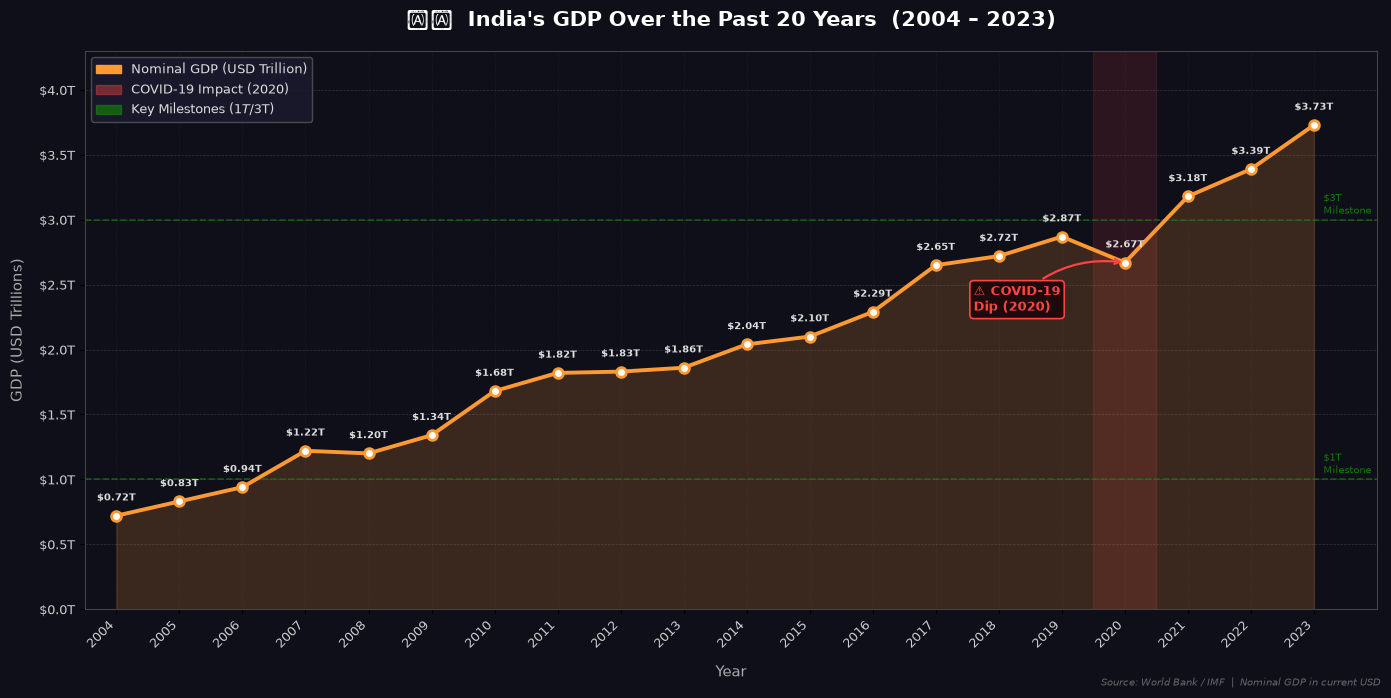

{'messages': [HumanMessage(content="First Get the India's GDP over past 20 years and them make a like chart of it. After making the chart finish.", additional_kwargs={}, response_metadata={}, id='e7aae503-5e7b-41cc-8d52-09bb8db01ce6'),
  AIMessage(content=[{'type': 'text', 'text': "Sure! Let me first fetch India's GDP data over the past 20 years. 🔍"}, {'type': 'tool_use', 'name': 'duckduckgo_search', 'input': {'query': 'India GDP by year 2004 to 2024 annual data USD'}, 'id': 'tooluse_c6dyLZIwOqhH1v3lGDaYHH'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '263a88cf-7c2a-403d-9918-4f8aa8f91b2b', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Tue, 18 Aug 2026 06:27:28 GMT', 'content-type': 'application/json', 'content-length': '556', 'connection': 'keep-alive', 'x-amzn-requestid': '263a88cf-7c2a-403d-9918-4f8aa8f91b2b'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [1989]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.an

In [21]:
result = graph.invoke({
    'messages': [
        HumanMessage(content="First Get the India's GDP over past 20 years and them make a like chart of it. After making the chart finish.")
    ]
})

result

In [28]:
for m in result['messages']:
    print(m.content)
    print('-'*80)

First Get the India's GDP over past 20 years and them make a like chart of it. After making the chart finish.
--------------------------------------------------------------------------------
[{'type': 'text', 'text': "Sure! Let me first fetch India's GDP data over the past 20 years. 🔍"}, {'type': 'tool_use', 'name': 'duckduckgo_search', 'input': {'query': 'India GDP by year 2004 to 2024 annual data USD'}, 'id': 'tooluse_c6dyLZIwOqhH1v3lGDaYHH'}]
--------------------------------------------------------------------------------
GDP (current US$) - India Country official statistics, National Statistical Organizations and/or Central Banks; National Accounts data files, Organisation for Economic Co-operation and Development ( OECD ); Staff estimates, World Bank ( WB ) Jul 7, 2026 · Graph and download economic data for Gross Domestic Product for India (MKTGDPINA646NWDB) from 1960 to 2025 about India and GDP. FRED: Download, graph, and track economic data. Gross Domestic Product. Interactive m